To fix: pip install imbalanced-learn
Step 1: Loading & Cleaning Data
Loaded raw data. Shape: (24388, 6)
   - Removed 1 exact duplicate rows.
   - Removed 547 duplicate (Title + Name) pairs.
   - Removed 3 rows with invalid/short titles.
Final Cleaned Shape: (23837, 6)

Step 2: Prepare the Data
------------------------------
Substep Output: Data after Trend Categorization (First 10 lines)
------------------------------
                                       Cleaned_Title  Relative_Change Trend
0  100 startups participate in maxis market acces...        -0.009690  flat
1         1689 stake in subur tiasa traded offmarket         0.000000  flat
2  najib wanted 1mdbs genting sanyen deal sped up...        -0.004902  flat
3         25bps opr cut likely in 2h20 says manulife         0.000000  flat
4  a 25month extension on concession pushes pharm...        -0.072519  flat
5                37 of yong tai transacted offmarket         0.025641  flat
6                  3a ruberex thriven kanger u

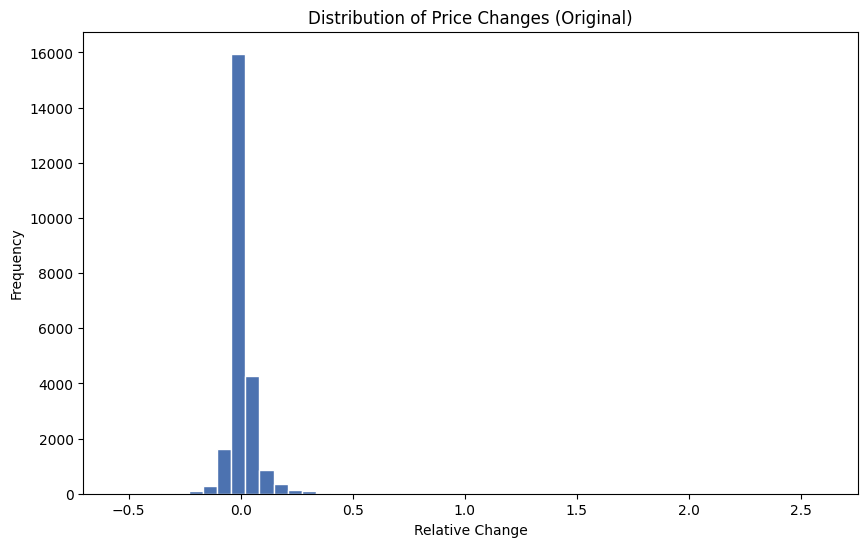

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# importing SMOTE (Requires: pip install imbalanced-learn)
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    print("Warning: 'imbalanced-learn' not found. SMOTE step will be skipped.")
    print("To fix: pip install imbalanced-learn")


# 1. Load and Clean the Dataset

print("Step 1: Loading & Cleaning Data")
try:
    df = pd.read_csv('stock_trend.csv')
    print(f"Loaded raw data. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'stock_trend.csv' not found.")
    exit()

# 1.1 Remove Exact Duplicates

initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"   - Removed {initial_rows - len(df)} exact duplicate rows.")

# 1.2 Remove Duplicate News for Same Company

rows_before_dedup = len(df)
df.drop_duplicates(subset=['Title', 'Name'], keep='first', inplace=True)
print(f"   - Removed {rows_before_dedup - len(df)} duplicate (Title + Name) pairs.")

# 1.3 Remove "Garbage" Rows (Short Titles)

rows_before_short = len(df)
df = df[df['Title'].str.len() > 5]
print(f"   - Removed {rows_before_short - len(df)} rows with invalid/short titles.")
print(f"Final Cleaned Shape: {df.shape}\n")


# 2. Prepare the Data (Feature Engineering)

print("Step 2: Prepare the Data")

# 2.1 Calculate Relative Price Change

df['Relative_Change'] = (df['After'] - df['Before']) / df['Before']

# 2.2 Define Trend Logic
def categorize_trend(change):
    if change > 0.10:
        return 'uptrend'
    elif change < -0.10:
        return 'downtrend'
    else:
        return 'flat'

df['Trend'] = df['Relative_Change'].apply(categorize_trend)

# 2.3 Advanced Features
# Time Features

df['Time'] = pd.to_datetime(df['Time'], utc=True)
df['Day_of_Week'] = df['Time'].dt.day_name()
df['Is_Weekend'] = df['Time'].dt.dayofweek >= 5

# Text Statistics

df['Title_Word_Count'] = df['Title'].apply(lambda x: len(str(x).split()))

# Company Volatility

company_volatility = df.groupby('Name')['Relative_Change'].transform('std')
df['Company_Historical_Vol'] = company_volatility.fillna(0)

# NLP Text Cleaning

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['Cleaned_Title'] = df['Title'].apply(clean_text)

# Print 10 lines after prep

print("-" * 30)
print("Substep Output: Data after Trend Categorization (First 10 lines)")
print("-" * 30)
print(df[['Cleaned_Title', 'Relative_Change', 'Trend']].head(10))
print("\n")

# 3. Split the Data

print("Step 3: Split the Data")

# Strategy: 70% Train, 20% Val, 10% Test
# First Split: 70% Train, 30% Temp

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['Trend'])

# Second Split: Temp -> 20% Val, 10% Test

val_df, test_df = train_test_split(temp_df, test_size=1/3, random_state=42, stratify=temp_df['Trend'])

print("-" * 30)
print(f"Substep Output: Training Set (First 10 lines)")
print("-" * 30)
print(train_df[['Title', 'Trend']].head(10))

print("\n" + "-" * 30)
print(f"Substep Output: Validation Set (First 10 lines)")
print("-" * 30)
print(val_df[['Title', 'Trend']].head(10))

print("\n" + "-" * 30)
print(f"Substep Output: Test Set (First 10 lines)")
print("-" * 30)
print(test_df[['Title', 'Trend']].head(10))

# 4. Save & Visualize Basics

print("\nStep 4: Save & Visualize")
train_df.to_csv('train_data_final.csv', index=False)
val_df.to_csv('val_data_final.csv', index=False)
test_df.to_csv('test_data_final.csv', index=False)
print("Datasets saved successfully (Text versions).")

# Visualize Original Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Relative_Change'], bins=50, color='#4c72b0', edgecolor='white')
plt.title('Distribution of Price Changes (Original)')
plt.xlabel('Relative Change')
plt.ylabel('Frequency')
plt.savefig('distribution_plot.png')
print("Visualization saved as 'distribution_plot.png'.")


# 5. IMPLEMENTING SMOTE (Handling Imbalance)

if SMOTE_AVAILABLE:
    print("\nStep 5: Handling Class Imbalance (SMOTE)")
    
    print("1. Original Class Distribution (Train):")
    print(train_df['Trend'].value_counts())
    
    # 5.1 Vectorize Text (SMOTE requires numbers, not strings)
    print("\n2. Vectorizing text data (TF-IDF)...")
    tfidf = TfidfVectorizer(max_features=5000)
    
    # Fit only on Train to prevent leakage
    X_train_tfidf = tfidf.fit_transform(train_df['Cleaned_Title'])
    y_train = train_df['Trend']
    
    # 5.2 Apply SMOTE
    print("3. Applying SMOTE to generate synthetic samples...")
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)
    
    # 5.3 Show Results
    print("\nSMOTE Complete!")
    print(f"   Before SMOTE Shape: {X_train_tfidf.shape}")
    print(f"   After SMOTE Shape:  {X_train_resampled.shape}")
    print("\n" + "-" * 30)
    print("Substep Output: SMOTE Resampled Data (First 10 lines)")
    print("(Note: SMOTE generates synthetic vectors, not text)")
    print("-" * 30)
    
    # Convert first 10 rows of sparse matrix to dense array for display
    # Showing the Labels and a snippet of the Feature Vector
    
    # Create a small temporary dataframe just for visualization
    preview_smote = pd.DataFrame(
        X_train_resampled[:10].toarray()[:, :5], # Show only first 5 features to fit screen
        columns=[f'Feature_{i}' for i in range(5)]
    )
    preview_smote['Trend_Label'] = y_train_resampled.head(10).values
    
    print(preview_smote)
    print(f"... (Total Features: {X_train_resampled.shape[1]})")
    
    print("\nFinal Class Distribution after SMOTE:")
    print(y_train_resampled.value_counts())
    
    # 5.4 Visualize Balance
    plt.figure(figsize=(8, 5))
    y_train_resampled.value_counts().plot(kind='bar', color=['#4c72b0', '#55a868', '#c44e52'])
    plt.title('Class Distribution After SMOTE')
    plt.xlabel('Trend')
    plt.ylabel('Count')
    plt.savefig('smote_balance.png')
    print("Balance plot saved as 'smote_balance.png'.")
    
    print("\nNOTE: 'X_train_resampled' is now a Sparse Matrix ready for Model Training.")
else:
    print("\nStep 5: SMOTE Skipped")
    print("Please install imbalanced-learn to run this step.")

In [7]:
import numpy as np
import pandas as pd

from nltk.tokenize import TweetTokenizer
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Flatten, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

import gensim.downloader as api
from tqdm import tqdm

print("Python:", __import__("sys").executable)
print("TF:", tf.__version__)

train_df = pd.read_csv("train_data_final.csv")
val_df   = pd.read_csv("val_data_final.csv")
test_df  = pd.read_csv("test_data_final.csv")

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

# show 5 rows
train_df[["Cleaned_Title", "Trend"]].head()

Python: c:\Users\danni\anaconda3\envs\cpc353\python.exe
TF: 2.15.0
Train: (16685, 13)
Val:   (4768, 13)
Test:  (2384, 13)


,Cleaned_Title,Trend
0,amcorp properties jumps 1087 on solid 3q earnings,flat
1,axiata dialog nova msc eco world international...,flat
2,investors resume shorting of top glove superma...,flat
3,green packet in position to trade higher says ...,flat
4,top glove jaycorp lafarge slp resources hong l...,flat


In [8]:
label2idx = {"downtrend": 0, "flat": 1, "uptrend": 2}
idx2label = {v: k for k, v in label2idx.items()}

y_train = train_df["Trend"].map(label2idx).values
y_val   = val_df["Trend"].map(label2idx).values
y_test  = test_df["Trend"].map(label2idx).values

print("Train label distribution:")
u, c = np.unique(y_train, return_counts=True)
for uu, cc in zip(u, c):
    print(idx2label[uu], ":", cc)

y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat   = to_categorical(y_val,   num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)


Train label distribution:
downtrend : 365
flat : 15466
uptrend : 854


In [9]:
print("Loading GloVe (glove-wiki-gigaword-50)...")
glove_model = api.load("glove-wiki-gigaword-50")
embedding_dim = glove_model.vector_size
print("Embedding dim:", embedding_dim)


Loading GloVe (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Embedding dim: 50


In [10]:
tokenizer = TweetTokenizer()

def texts_to_embeddings(texts, max_len, glove_model, emb_dim):
    seqs = []
    for text in tqdm(texts, desc="Embedding"):
        tokens = tokenizer.tokenize(str(text).lower())
        vectors = []
        for tok in tokens:
            if tok in glove_model:
                vectors.append(glove_model[tok])
            else:
                # OOV handling (random vector)
                vectors.append(np.random.normal(scale=0.6, size=emb_dim))
        if len(vectors) == 0:
            vectors.append(np.zeros(emb_dim))
        seqs.append(np.array(vectors))

    return pad_sequences(
        seqs,
        maxlen=max_len,
        dtype="float32",
        padding="post",
        truncating="post"
    )

max_len = 30

X_train = texts_to_embeddings(train_df["Cleaned_Title"], max_len, glove_model, embedding_dim)
X_val   = texts_to_embeddings(val_df["Cleaned_Title"],   max_len, glove_model, embedding_dim)
X_test  = texts_to_embeddings(test_df["Cleaned_Title"],  max_len, glove_model, embedding_dim)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)


Embedding: 100%|██████████| 2384/2384 [00:00<00:00, 10773.65it/s]

X_train: (16685, 30, 50)
X_val:   (4768, 30, 50)
X_test:  (2384, 30, 50)


In [11]:
inputs = Input(shape=(max_len, embedding_dim))
x = LSTM(64, return_sequences=True)(inputs)
x = Flatten()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation="softmax")(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()




Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 50)]          0         
                                                                 
 lstm (LSTM)                 (None, 30, 64)            29440     
                                                                 
 flatten (Flatten)           (None, 1920)              0         
                                                                 
 dense (Dense)               (None, 32)                61472     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 3)                 99        
                                                                 
Total params: 91011 (355.51 KB)
Trainable params: 91011 (35

In [12]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10


522/522 [==============================] - 7s 11ms/step - loss: 0.3515 - accuracy: 0.9244 - val_loss: 0.2905 - val_accuracy: 0.9268
Epoch 2/10
522/522 [==============================] - 5s 9ms/step - loss: 0.3110 - accuracy: 0.9268 - val_loss: 0.2866 - val_accuracy: 0.9268
Epoch 3/10
522/522 [==============================] - 4s 8ms/step - loss: 0.2930 - accuracy: 0.9271 - val_loss: 0.2829 - val_accuracy: 0.9268
Epoch 4/10
522/522 [==============================] - 5s 9ms/step - loss: 0.2738 - accuracy: 0.9277 - val_loss: 0.2859 - val_accuracy: 0.9249
Epoch 5/10
522/522 [==============================] - 5s 10ms/step - loss: 0.2600 - accuracy: 0.9288 - val_loss: 0.2916 - val_accuracy: 0.9243
Epoch 6/10
522/522 [==============================] - 5s 10ms/step - loss: 0.2450 - accuracy: 0.9290 - val_loss: 0.2937 - val_accuracy: 0.9243
Epoch 7/10
522/522 [==============================] - 5s 10ms/step - loss: 0.2278 - accuracy: 0.9291 - val_loss: 0.3037 - val_accuracy: 0.9237


In [13]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["downtrend", "flat", "uptrend"],
    digits=4
))

75/75 [==============================] - 1s 4ms/step
Test Accuracy: 0.9224

Classification Report:
              precision    recall  f1-score   support

   downtrend     0.0000    0.0000    0.0000        52
        flat     0.9281    0.9932    0.9596      2210
     uptrend     0.2105    0.0328    0.0567       122

    accuracy                         0.9224      2384
   macro avg     0.3795    0.3420    0.3388      2384
weighted avg     0.8712    0.9224    0.8924      2384



c:\Users\danni\anaconda3\envs\cpc353\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\danni\anaconda3\envs\cpc353\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\danni\anaconda3\envs\cpc353\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh